In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


# 📊 Customer Churn Prediction Using Machine Learning

## 🎯 Project Overview

Customer churn is an important business problem where customers stop using a company's products or services.

In this project, we analyze customer information and develop machine learning models to predict whether a customer is likely to churn.

The project follows a complete data science workflow:

**Data Collection → Data Cleaning → Exploratory Data Analysis → Feature Engineering → Model Training → Model Evaluation → Feature Analysis**

---

## 🎯 Objectives

- Understand customer churn patterns.
- Explore relationships between customer characteristics and churn.
- Prepare customer data for machine learning.
- Build classification models to predict churn.
- Compare model performance using multiple evaluation metrics.
- Identify features that contribute strongly to model predictions.

---

## 🛠️ Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

---

## 📂 Dataset

The project uses the **Telco Customer Churn** dataset.

The cleaned dataset contains **7,032 customer records and 21 columns** after handling missing `TotalCharges` values.

The target variable is:

- `Churn = No` → Customer stayed
- `Churn = Yes` → Customer churned

---

## 🔬 Machine Learning Models

The following classification models were evaluated:

1. Logistic Regression
2. Random Forest Classifier

Model performance was evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

---

## 📌 Project Outcome

The project demonstrates how customer data can be explored, processed, and used to build machine learning models for churn prediction.

In [2]:
# ==========================================
# Customer Churn Prediction
# Machine Learning Project
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [4]:
# Load the dataset

file_path = "/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Basic dataset information

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
cus

In [6]:
# Convert TotalCharges to numeric
# Invalid/blank values will become NaN

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values after conversion:")
print(df["TotalCharges"].isnull().sum())

Missing values after conversion:
11


In [7]:
# Remove rows with missing TotalCharges

df = df.dropna(subset=["TotalCharges"])

print("Dataset shape after cleaning:", df.shape)
print("Remaining missing values:", df["TotalCharges"].isnull().sum())

Dataset shape after cleaning: (7032, 21)
Remaining missing values: 0


In [8]:
# Churn distribution

print("Churn counts:")
print(df["Churn"].value_counts())

print("\nChurn percentage:")
print(df["Churn"].value_counts(normalize=True).mul(100).round(2))

Churn counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


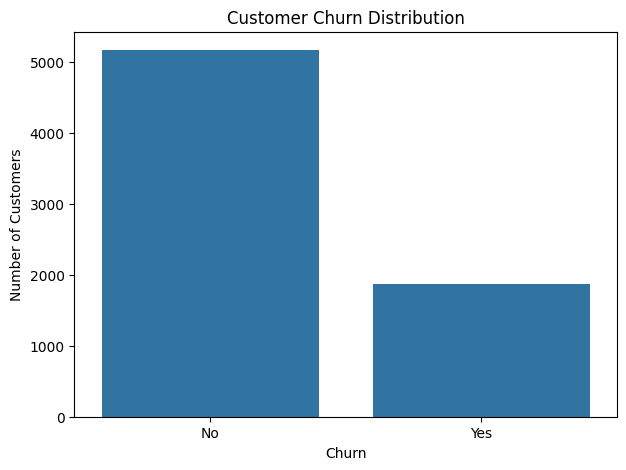

In [9]:
# Churn Distribution Visualization

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

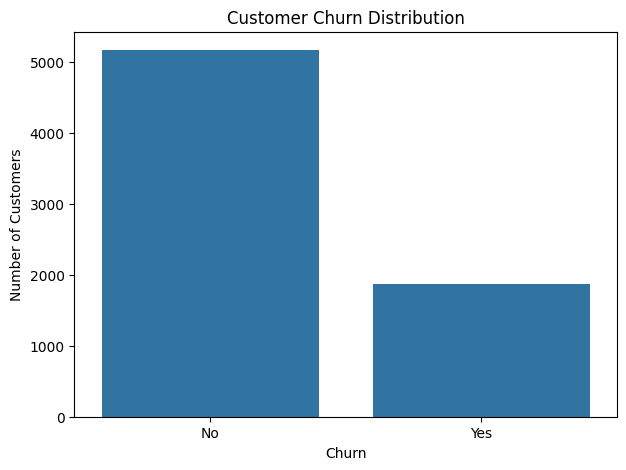

In [10]:
# Churn Distribution Visualization

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

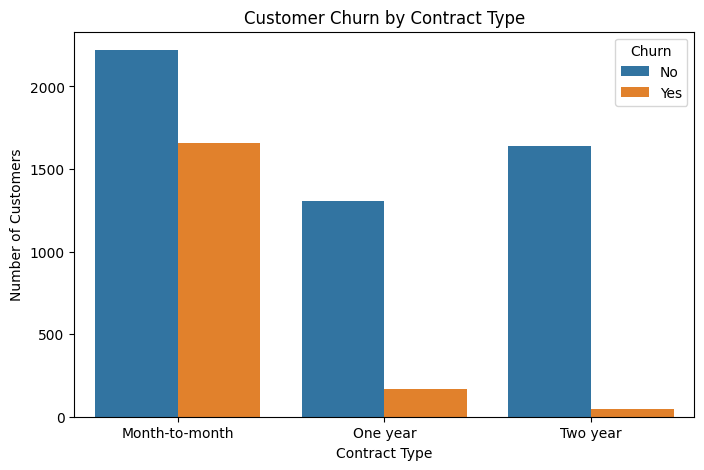

In [11]:
# Churn by Contract Type

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

### 💡 Insight: Churn by Contract Type

The distribution shows that churn is concentrated among month-to-month customers, while customers with one-year and two-year contracts have fewer churn cases.

This suggests that contract type is an important feature to consider when predicting customer churn. However, this analysis shows an association rather than a causal relationship.

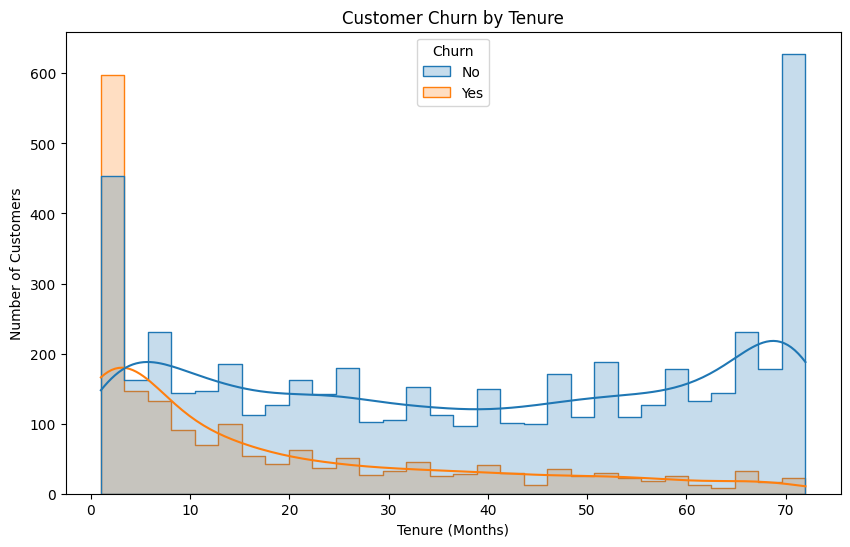

In [12]:
# Churn by Customer Tenure

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Customer Churn by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

### 💡 Insight: Churn and Customer Tenure

The distribution suggests that customers with shorter tenure account for a larger share of churn cases. Churn cases decrease as customer tenure increases.

Customer tenure may therefore be a useful feature for the machine learning model when predicting churn.

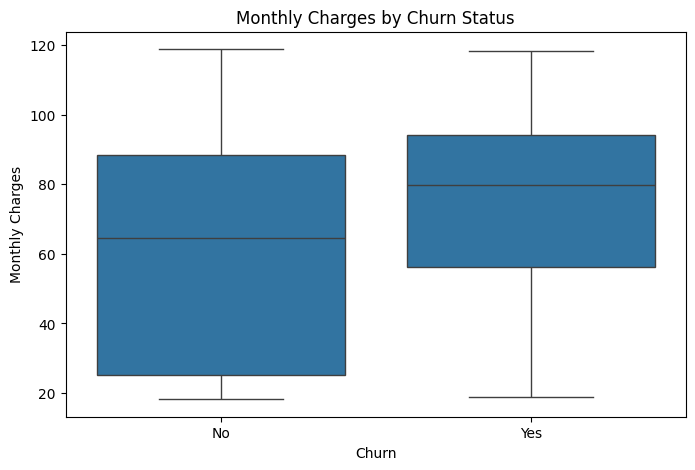

In [13]:
# Monthly Charges by Churn

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

### 💡 Insight: Monthly Charges and Churn

Customers who churned have a higher median monthly charge than customers who stayed in this dataset.

However, the distributions overlap considerably, so monthly charges alone are not sufficient to explain customer churn. We will combine this feature with other customer attributes in the machine learning model.

In [14]:
# Prepare features and target

X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"].map({"No": 0, "Yes": 1})

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Features shape: (7032, 19)
Target shape: (7032,)

Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [15]:
# Encode categorical features

X_encoded = pd.get_dummies(X, drop_first=True, dtype=int)

print("Encoded feature shape:", X_encoded.shape)
print("\nFirst 5 rows:")
display(X_encoded.head())

Encoded feature shape: (7032, 30)

First 5 rows:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


In [16]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set: (5625, 30)
Testing set: (1407, 30)

Training target distribution:
Churn
0    4130
1    1495
Name: count, dtype: int64

Testing target distribution:
Churn
0    1033
1     374
Name: count, dtype: int64


In [17]:
# Scale numerical features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Feature scaling completed!
Training shape: (5625, 30)
Testing shape: (1407, 30)


In [18]:
# Train Logistic Regression with scaled features

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [19]:
# Evaluate the model

y_pred = logistic_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8038

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



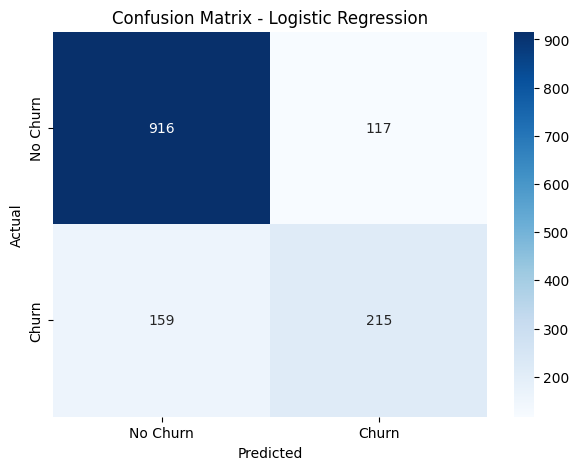

In [20]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### 💡 Confusion Matrix Interpretation

The confusion matrix shows how the Logistic Regression model performs on both classes.

- **916** customers were correctly predicted as No Churn.
- **215** customers were correctly predicted as Churn.
- **117** No Churn customers were incorrectly predicted as Churn.
- **159** Churn customers were incorrectly predicted as No Churn.

The model provides a useful baseline, but there is room to improve its ability to identify customers who are likely to churn.

In [21]:
# Train Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [22]:
# Evaluate Random Forest

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7903

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [23]:
# Compare model performance

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Churn Recall": [
        classification_report(y_test, y_pred, output_dict=True)["1"]["recall"],
        classification_report(y_test, rf_pred, output_dict=True)["1"]["recall"]
    ],
    "Churn F1-Score": [
        classification_report(y_test, y_pred, output_dict=True)["1"]["f1-score"],
        classification_report(y_test, rf_pred, output_dict=True)["1"]["f1-score"]
    ]
})

comparison

,Model,Accuracy,Churn Recall,Churn F1-Score
0,Logistic Regression,0.803838,0.574866,0.609065
1,Random Forest,0.790334,0.502674,0.560358


## 🤖 Model Comparison

Two classification models were evaluated:

1. Logistic Regression
2. Random Forest

The comparison considers accuracy as well as recall and F1-score for the churn class. Since identifying customers who may churn is an important part of this problem, evaluating the churn-class metrics provides additional information beyond overall accuracy.

The models will be further evaluated using their confusion matrices and feature importance where appropriate.

In [24]:
# Random Forest Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(15))

,Feature,Importance
3,TotalCharges,0.178580
1,tenure,0.161990
2,MonthlyCharges,0.151937
25,Contract_Two year,0.060670
10,InternetService_Fiber optic,0.038928
28,PaymentMethod_Electronic check,0.037873
24,Contract_One year,0.030572
13,OnlineSecurity_Yes,0.029054
4,gender_Male,0.025515
26,PaperlessBilling_Yes,0.023523


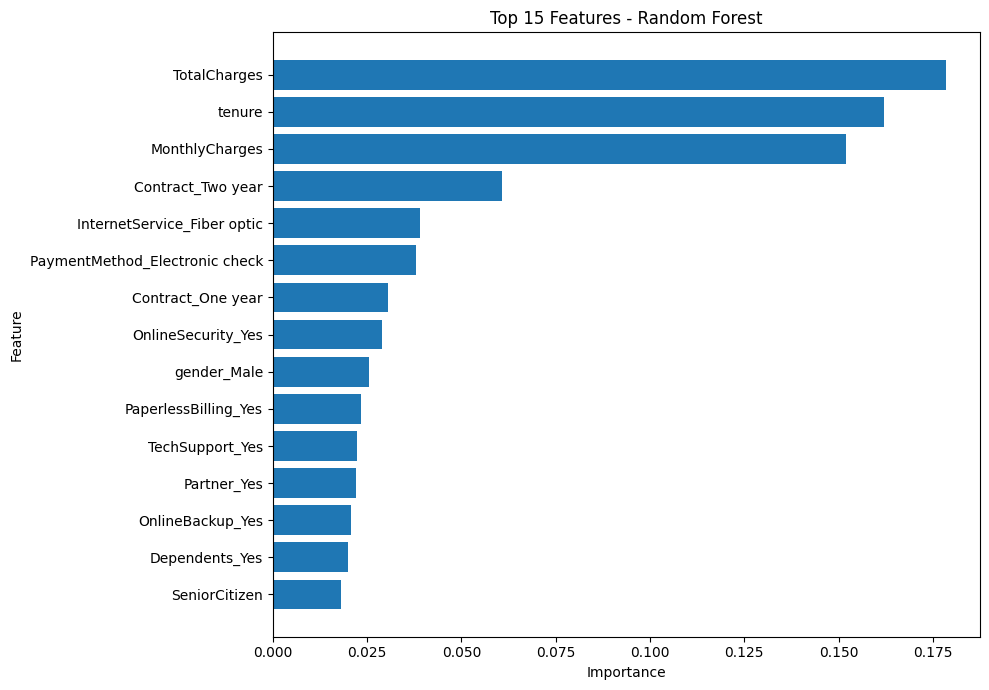

In [25]:
# Top 15 Feature Importances

top_features = feature_importance.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### 💡 Feature Importance Insights

The Random Forest model assigns the highest feature-importance values to `TotalCharges`, `tenure`, and `MonthlyCharges`.

Contract type and several service-related features also contribute to the model's predictions.

Feature importance indicates how much a feature contributes to the Random Forest's predictions; it should not be interpreted as evidence that a feature directly causes customer churn.

# 📌 Project Conclusion

## Summary

In this project, we developed a machine learning pipeline to predict customer churn using the Telco Customer Churn dataset.

### 🔍 Key Steps

- Loaded and cleaned the customer churn dataset.
- Converted `TotalCharges` to a numeric format and handled missing values.
- Performed exploratory data analysis using visualizations.
- Investigated churn patterns across contract type, tenure, and monthly charges.
- Encoded categorical variables using one-hot encoding.
- Split the data into training and testing sets.
- Trained and evaluated Logistic Regression and Random Forest models.
- Compared model performance using accuracy, churn recall, and F1-score.
- Examined Random Forest feature importance.

### 🤖 Model Results

| Model | Accuracy | Churn Recall | Churn F1-Score |
|---|---:|---:|---:|
| Logistic Regression | 80.38% | 57.49% | 60.91% |
| Random Forest | 79.03% | 50.27% | 56.04% |

### 💡 Key Findings

The exploratory analysis showed that churn cases were more concentrated among month-to-month customers and customers with shorter tenure.

The Random Forest feature-importance analysis assigned relatively high importance to `TotalCharges`, `tenure`, and `MonthlyCharges`.

These findings describe patterns in this dataset and do not establish causal relationships.

### 🚀 Future Improvements

Future versions of this project could explore:

- Hyperparameter tuning
- Cross-validation
- XGBoost and other boosting models
- Class-imbalance techniques
- Probability threshold optimization
- Model explainability using SHAP
- Deployment using Streamlit or another web framework